# Zomato Ratings — Predictive Model

**Goal:** combine everything from the EDA and NLP notebooks into a single model that predicts a restaurant's rating bucket, and use feature importance to state — with evidence, not just visual impressions — what actually drives ratings.

This notebook depends on `sentiment_score` from the NLP notebook. If you haven't run `03_nlp_sentiment.ipynb` in this session, some of this won't have that column available from a saved file, so we recompute it here fresh to keep this notebook self-contained.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/zomato_clean.csv")
print(df.shape)


(9215, 15)


## 1. Recreate sentiment score
Same VADER approach as the NLP notebook, kept here so this notebook can run standalone.

In [2]:
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text, max_chars=5000):
    text = str(text)[:max_chars]
    if text == "nan" or len(text) == 0:
        return 0.0
    return sia.polarity_scores(text)["compound"]

df["sentiment_score"] = df["review_text_combined"].apply(get_sentiment)
print("Sentiment scores computed")


Sentiment scores computed


## 2. Define the prediction target
Rather than predicting the exact rating (a hard regression problem with lots of noise), we bucket ratings into three tiers — this is more useful for a business anyway ("is this restaurant Low/Medium/High rated") and easier to explain in a portfolio project.

- **Low**: rate < 3.5
- **Medium**: 3.5 <= rate < 4.0
- **High**: rate >= 4.0


rating_bucket
Medium    4027
Low       3055
High      2133
Name: count, dtype: int64


C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_12756\2066321018.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="rating_bucket", order=["Low", "Medium", "High"], palette="Set2")


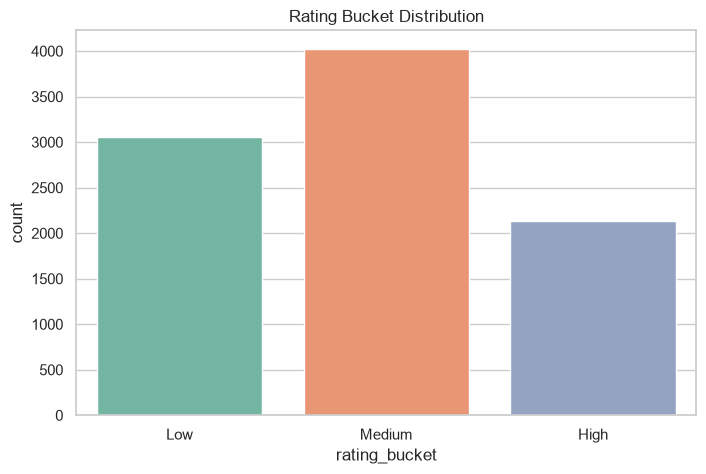

In [3]:
def rating_bucket(r):
    if r < 3.5:
        return "Low"
    elif r < 4.0:
        return "Medium"
    else:
        return "High"

df["rating_bucket"] = df["rate"].apply(rating_bucket)
print(df["rating_bucket"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating_bucket", order=["Low", "Medium", "High"], palette="Set2")
plt.title("Rating Bucket Distribution")
plt.show()


## 3. Feature engineering
Pick features that are known *before* a rating exists (cost, cuisine, location, online order, book table, sentiment) — this is important: we should not use `votes` since that's a consequence of popularity/rating, not a cause, and would leak information about the target.

In [4]:
model_df = df.copy()

# Get the primary (first-listed) cuisine as a simpler categorical feature
model_df["primary_cuisine"] = model_df["cuisines"].fillna("Unknown").str.split(",").str[0].str.strip()
model_df["cuisine_count"] = model_df["cuisines"].fillna("").str.split(",").apply(lambda x: len(x) if x != [""] else 0)

# Keep only cuisines and locations with enough restaurants to be meaningful categories;
# lump everything else into "Other" to avoid an explosion of tiny categories
top_cuisines = model_df["primary_cuisine"].value_counts()
top_cuisines = top_cuisines[top_cuisines >= 50].index
model_df["primary_cuisine"] = model_df["primary_cuisine"].where(
    model_df["primary_cuisine"].isin(top_cuisines), "Other"
)

top_locations = model_df["location"].value_counts()
top_locations = top_locations[top_locations >= 50].index
model_df["location_grouped"] = model_df["location"].where(
    model_df["location"].isin(top_locations), "Other"
)

# rest_type can have multiple values like "Casual Dining, Bar" -- take the primary one
model_df["primary_rest_type"] = model_df["rest_type"].fillna("Unknown").str.split(",").str[0].str.strip()
top_rest_types = model_df["primary_rest_type"].value_counts()
top_rest_types = top_rest_types[top_rest_types >= 50].index
model_df["primary_rest_type"] = model_df["primary_rest_type"].where(
    model_df["primary_rest_type"].isin(top_rest_types), "Other"
)

# Richer review-text signal beyond a single sentiment score --
# review length and volume often carry real information (very short review
# sets tend to be noisier/less reliable ratings; longer, more detailed
# reviews often correlate with more engaged, more critical customers)
model_df["review_text_length"] = model_df["review_text_combined"].fillna("").str.len()
model_df["dish_liked_count"] = model_df["dish_liked"].fillna("").apply(
    lambda x: 0 if x == "" else len(str(x).split(","))
)

numeric_features = ["cost_for_two", "online_order", "book_table", "sentiment_score",
                     "cuisine_count", "review_count_parsed", "review_text_length",
                     "dish_liked_count"]
categorical_features = ["primary_cuisine", "location_grouped", "primary_rest_type"]
target = "rating_bucket"

model_df = model_df.dropna(subset=numeric_features + categorical_features + [target])
print(f"{len(model_df):,} restaurants available for modeling")


9,215 restaurants available for modeling


In [5]:
# Target encoding instead of one-hot: for tree models, high-cardinality
# categoricals (many distinct locations/cuisines/rest types) work better as
# a single dense numeric column than as dozens of sparse 0/1 columns, which
# Random Forest struggles to split on effectively.
#
# We encode each category as the mean numeric rating of restaurants in that
# category, computed ONLY on the training set to avoid leaking test-set
# information into the encoding.

X_full = model_df[numeric_features + categorical_features + ["rate"]].reset_index(drop=True)
y_full = model_df[target].reset_index(drop=True)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

for col in categorical_features:
    category_means = X_train_raw.groupby(col)["rate"].mean()
    global_mean = X_train_raw["rate"].mean()
    X_train_raw[col + "_target_enc"] = X_train_raw[col].map(category_means)
    # Categories in test set not seen during training fall back to the global mean
    X_test_raw[col + "_target_enc"] = X_test_raw[col].map(category_means).fillna(global_mean)

encoded_cols = [c + "_target_enc" for c in categorical_features]
X_train = X_train_raw[numeric_features + encoded_cols]
X_test = X_test_raw[numeric_features + encoded_cols]

print(f"Total features: {X_train.shape[1]}")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")


Total features: 11
Train: 7,372 | Test: 1,843


## 4. Train the model
A Random Forest is a good default here as it handles non-linear relationships, doesn't need feature scaling, and gives us feature importance directly.

In [6]:
model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.674

              precision    recall  f1-score   support

        High       0.71      0.80      0.75       427
         Low       0.68      0.69      0.68       611
      Medium       0.65      0.60      0.62       805

    accuracy                           0.67      1843
   macro avg       0.68      0.70      0.69      1843
weighted avg       0.67      0.67      0.67      1843



## 6. Trying to legitimately push accuracy further
Two changes here: (1) added review length and dish-liked count as extra features, since sentiment score alone compresses a lot of review information into one number, and (2) switching to Gradient Boosting, which often outperforms Random Forest on tabular data like this, plus a small hyperparameter search instead of hand-picked settings.


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_iter": [200, 400],
    "max_depth": [6, 10, None],
    "learning_rate": [0.05, 0.1],
}

hgb = HistGradientBoostingClassifier(random_state=42)
search = GridSearchCV(hgb, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
best_model = search.best_estimator_

y_pred_hgb = best_model.predict(X_test)
print(f"\nTuned HistGradientBoosting accuracy: {accuracy_score(y_test, y_pred_hgb):.3f}")
print()
print(classification_report(y_test, y_pred_hgb))


C:\Users\Anushka Ghat\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Anushka Ghat\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Anushka Ghat\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Anushka Ghat\AppData

Best params: {'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 200}

Tuned HistGradientBoosting accuracy: 0.664

              precision    recall  f1-score   support

        High       0.73      0.74      0.74       427
         Low       0.68      0.63      0.65       611
      Medium       0.62      0.65      0.63       805

    accuracy                           0.66      1843
   macro avg       0.68      0.67      0.67      1843
weighted avg       0.67      0.66      0.66      1843



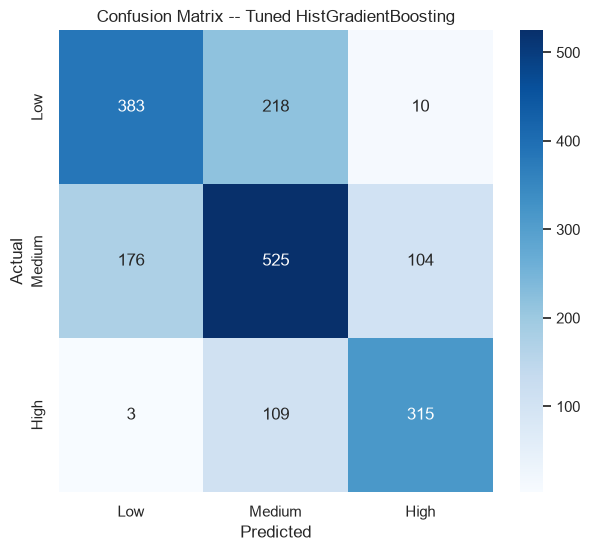

In [8]:
cm_hgb = confusion_matrix(y_test, y_pred_hgb, labels=["Low", "Medium", "High"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm_hgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -- Tuned HistGradientBoosting")
plt.show()


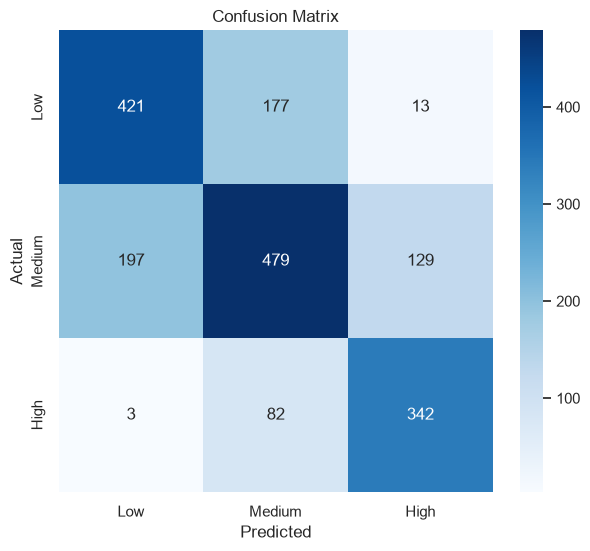

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 5. Feature importance — the headline result
This is the evidence-backed answer to "what actually drives ratings" — no more eyeballing scatter plots, this is the model's own measure of how much each feature contributed to its predictions.

C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_12756\3109767058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


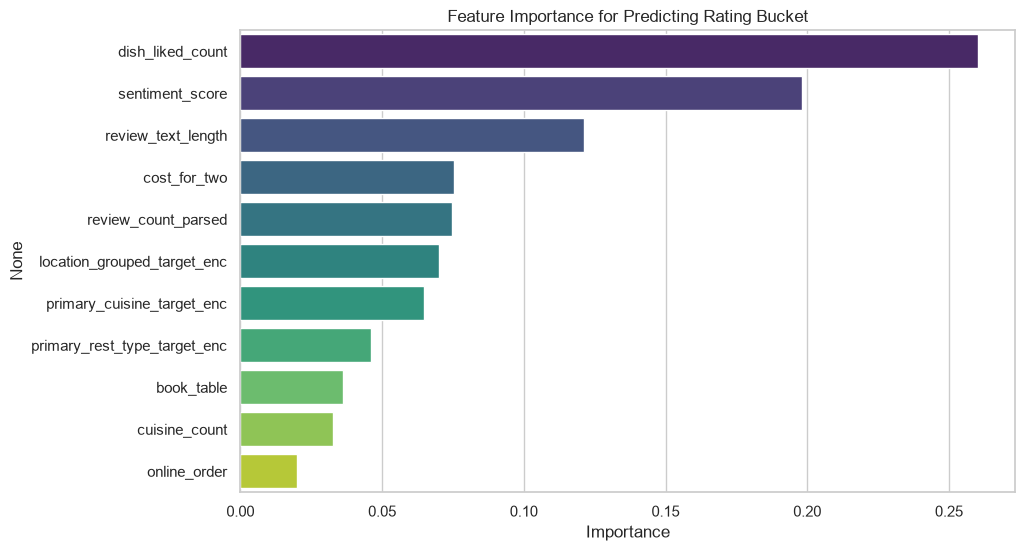

dish_liked_count                0.260421
sentiment_score                 0.198219
review_text_length              0.121285
cost_for_two                    0.075499
review_count_parsed             0.074590
location_grouped_target_enc     0.070235
primary_cuisine_target_enc      0.064801
primary_rest_type_target_enc    0.045960
book_table                      0.036352
cuisine_count                   0.032523
online_order                    0.020112
dtype: float64

In [10]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance for Predicting Rating Bucket")
plt.xlabel("Importance")
plt.show()

importances


In [11]:
import json

# Rating distribution (histogram bins)
hist_counts, hist_edges = np.histogram(df["rate"], bins=20)

# Cost vs rating (binned scatter, to keep file small — average rating per cost bucket)
df["cost_bucket"] = pd.cut(df["cost_for_two"], bins=15)
cost_rating = df.groupby("cost_bucket", observed=True)["rate"].mean().reset_index()
cost_rating["cost_mid"] = cost_rating["cost_bucket"].apply(lambda x: x.mid)

# Top cuisines
cuisine_df = df.assign(cuisines=df["cuisines"].str.split(",")).explode("cuisines")
cuisine_df["cuisines"] = cuisine_df["cuisines"].str.strip()
cuisine_stats = (
    cuisine_df.groupby("cuisines")["rate"]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
    .head(15)
    .reset_index()
)

# Top locations
location_stats = (
    df.groupby("location")["rate"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
    .head(15)
    .reset_index()
)

# Table booking / online order effect
booking_effect = df.groupby("book_table")["rate"].mean().to_dict()
order_effect = df.groupby("online_order")["rate"].mean().to_dict()

# Correlation numbers
cost_corr = df[["cost_for_two", "rate"]].corr().iloc[0, 1]
sentiment_corr = df[["sentiment_score", "rate"]].corr().iloc[0, 1] if "sentiment_score" in df.columns else None

# Feature importance (from the trained model)
feat_imp = importances.to_dict() if "importances" in dir() else {}

# Model metrics -- prefer the tuned HistGradientBoosting result if it was run,
# otherwise fall back to the original Random Forest result
if "y_pred_hgb" in dir():
    model_accuracy = float(accuracy_score(y_test, y_pred_hgb))
    model_used = "HistGradientBoosting (tuned)"
elif "y_pred" in dir():
    model_accuracy = float(accuracy_score(y_test, y_pred))
    model_used = "RandomForest"
else:
    model_accuracy = None
    model_used = None

dashboard_data = {
    "total_restaurants": int(len(df)),
    "mean_rating": float(df["rate"].mean()),
    "rating_histogram": {
        "counts": hist_counts.tolist(),
        "edges": hist_edges.tolist()
    },
    "cost_vs_rating": cost_rating[["cost_mid", "rate"]].dropna().to_dict(orient="records"),
    "cost_rating_correlation": float(cost_corr),
    "top_cuisines": cuisine_stats.to_dict(orient="records"),
    "top_locations": location_stats.to_dict(orient="records"),
    "booking_effect": {str(k): float(v) for k, v in booking_effect.items()},
    "order_effect": {str(k): float(v) for k, v in order_effect.items()},
    "sentiment_rating_correlation": float(sentiment_corr) if sentiment_corr is not None else None,
    "feature_importance": {k: float(v) for k, v in feat_imp.items()},
    "model_accuracy": model_accuracy,
    "model_used": model_used,
    "problem_restaurant_count": int(len(problem_restaurants)) if "problem_restaurants" in dir() else None,
}

with open("../dashboard/dashboard_data.json", "w") as f:
    json.dump(dashboard_data, f, indent=2)

print("Exported dashboard_data.json successfully")
print(json.dumps(dashboard_data, indent=2)[:2000])

Exported dashboard_data.json successfully
{
  "total_restaurants": 9215,
  "mean_rating": 3.631264243081932,
  "rating_histogram": {
    "counts": [
      1,
      7,
      4,
      33,
      29,
      146,
      144,
      481,
      413,
      1153,
      1323,
      788,
      1728,
      832,
      1158,
      361,
      414,
      102,
      73,
      25
    ],
    "edges": [
      1.8,
      1.955,
      2.1100000000000003,
      2.265,
      2.42,
      2.575,
      2.7300000000000004,
      2.8850000000000002,
      3.04,
      3.1950000000000003,
      3.3500000000000005,
      3.5050000000000003,
      3.66,
      3.8150000000000004,
      3.9700000000000006,
      4.125,
      4.28,
      4.4350000000000005,
      4.590000000000001,
      4.745,
      4.9
    ]
  },
  "cost_vs_rating": [
    {
      "cost_mid": 235.68650000000002,
      "rate": 3.553207236842105
    },
    {
      "cost_mid": 636.0,
      "rate": 3.6186892442772027
    },
    {
      "cost_mid": 1033.3335,
 



## Project wrap-up checklist
- [ ] Fill in summary sections across all 3 notebooks with real numbers
- [ ] Update README's "Findings" section
- [ ] Push notebooks + this summary to GitHub
- [ ] Build Power BI/Tableau dashboard (optional, from README plan)
- [ ] Write LinkedIn post using the strongest 2-3 findings
